In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [2]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.12.0+cpu
0.27.0+cpu


In [3]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [4]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

PyTorch: 2.12.0+cpu
TorchVision: 0.27.0+cpu


In [6]:
import torchvision
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [02:34<00:00, 1.10MB/s]


In [8]:
print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

Train: 50000
Test : 10000


In [10]:
import os

print(os.path.exists("./data/cifar-10-batches-py"))

True


In [11]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [12]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform
)

print("Train Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

Train Samples: 50000
Test Samples: 10000


In [13]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches:", len(train_loader))
print("Test Batches:", len(test_loader))

Train Batches: 391
Test Batches: 79


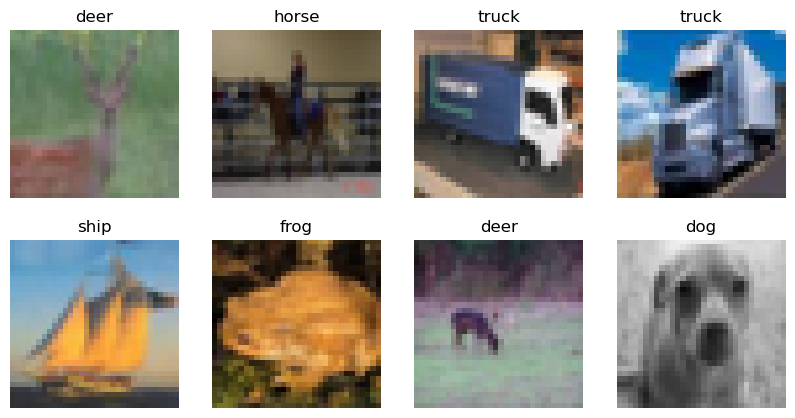

In [14]:
import matplotlib.pyplot as plt

classes = (
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0)

    plt.imshow(img)

    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

In [15]:
import torch
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*4*4,256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

model = CNN()

print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f}"
    )

Epoch [1/10] Loss: 661.5438
Epoch [2/10] Loss: 521.5908
Epoch [3/10] Loss: 462.8722
Epoch [4/10] Loss: 417.7214
Epoch [5/10] Loss: 387.4477
Epoch [6/10] Loss: 358.2882
Epoch [7/10] Loss: 335.6469
Epoch [8/10] Loss: 317.3883
Epoch [9/10] Loss: 296.7478
Epoch [10/10] Loss: 281.7124


In [19]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 72.41%


In [20]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.73      0.80      0.77      1000
           1       0.88      0.79      0.83      1000
           2       0.72      0.51      0.60      1000
           3       0.49      0.61      0.55      1000
           4       0.70      0.67      0.68      1000
           5       0.64      0.63      0.63      1000
           6       0.76      0.81      0.79      1000
           7       0.81      0.74      0.77      1000
           8       0.83      0.83      0.83      1000
           9       0.74      0.84      0.79      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



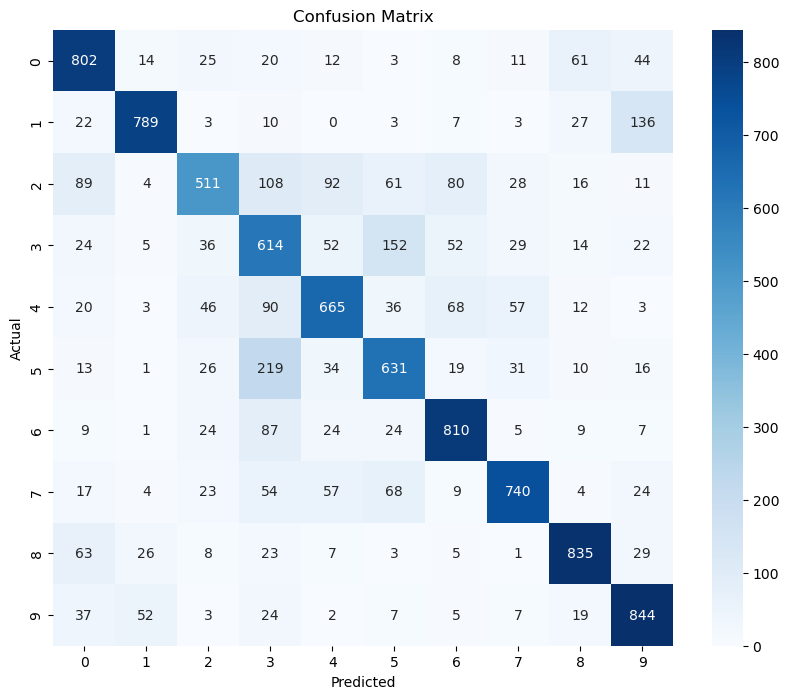

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
torch.save(
    model.state_dict(),
    "cnn_image_classifier.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
loss_history = []

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    loss_history.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}"
    )

Epoch [1/10] Loss: 0.6773
Epoch [2/10] Loss: 0.6432
Epoch [3/10] Loss: 0.6063
Epoch [4/10] Loss: 0.5769
Epoch [5/10] Loss: 0.5487
Epoch [6/10] Loss: 0.5243
Epoch [7/10] Loss: 0.4933
Epoch [8/10] Loss: 0.4710
Epoch [9/10] Loss: 0.4481
Epoch [10/10] Loss: 0.4259


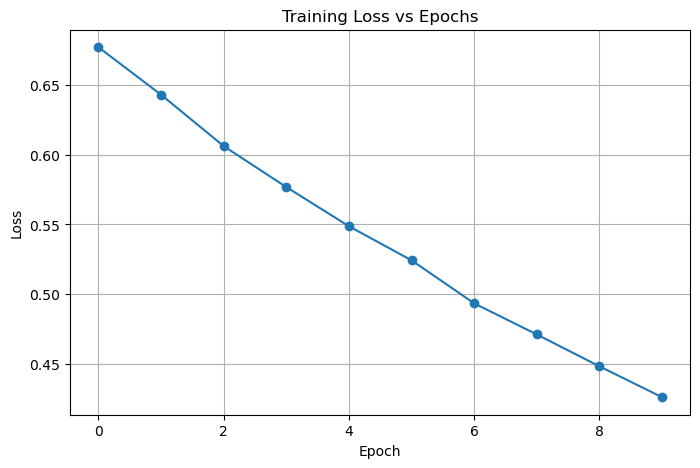

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history, marker='o')

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig("Training_Loss_Graph.png")

plt.show()

In [25]:
accuracy_history = []

epochs = 10

for epoch in range(epochs):

    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_accuracy = 100 * correct / total

    accuracy_history.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Accuracy: 85.18%
Epoch [2/10] Accuracy: 85.84%
Epoch [3/10] Accuracy: 86.33%
Epoch [4/10] Accuracy: 87.08%
Epoch [5/10] Accuracy: 87.31%
Epoch [6/10] Accuracy: 87.89%
Epoch [7/10] Accuracy: 88.22%
Epoch [8/10] Accuracy: 88.91%
Epoch [9/10] Accuracy: 89.11%
Epoch [10/10] Accuracy: 89.38%


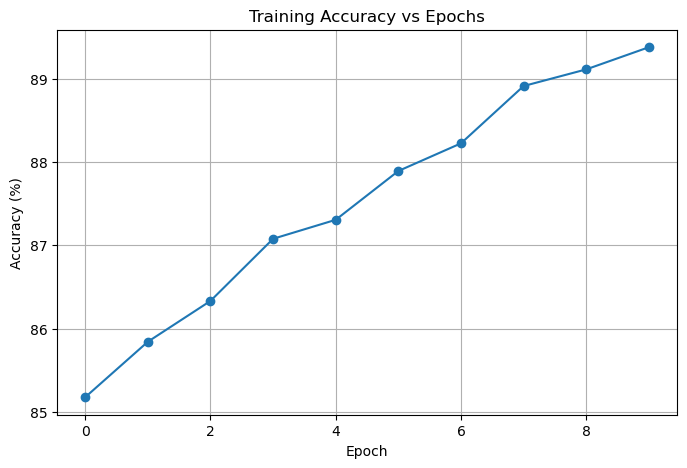

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    accuracy_history,
    marker='o'
)

plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.savefig("Accuracy_Graph.png")

plt.show()

In [27]:
print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


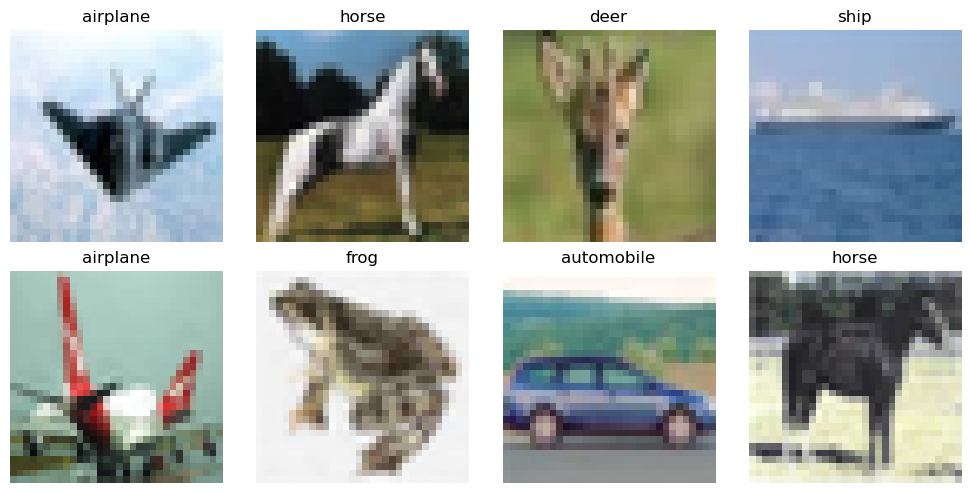

In [28]:
plt.figure(figsize=(10,5))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0)

    plt.imshow(img)

    plt.title(classes[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.savefig("Sample_CIFAR10_Images.png")

plt.show()

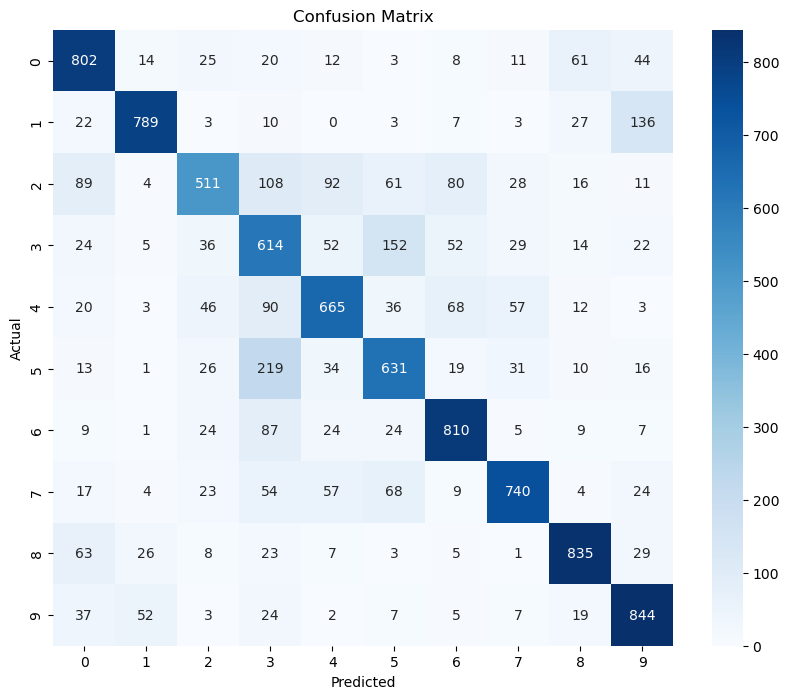

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("Confusion_Matrix.png")

plt.show()